# מטלת סיום – חלק 2 | Movie Rating Prediction

**שמות חברי הצוות + ת.ז.:** <FILL IN>

**קישור ל-GitHub:** <FILL IN>

In [1]:
# ============================================================
#  מטלת סיום – חלק 2 | Movie Rating Prediction
#  Chen Hajaj · Ariel University · Machine Learning
# ============================================================
# שמות חברי הצוות + ת.ז.:  <FILL IN>
# קישור ל-GitHub:            <FILL IN>
# ============================================================

## 1. ייבוא ספריות

In [2]:
import re
import ast
import bisect
import warnings
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

from sklearn.linear_model    import ElasticNet
from sklearn.ensemble        import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler
from sklearn.impute          import SimpleImputer
from sklearn.compose         import ColumnTransformer
from sklearn.metrics         import mean_squared_error, mean_absolute_error, r2_score
from sklearn.base            import BaseEstimator, TransformerMixin
from sklearn.model_selection import GridSearchCV

## 2. טעינת הדאטה

In [3]:
dataset = pd.read_csv("dataset.csv", na_values=['\\N', 'N/A', 'null'], low_memory=False)
# טעינת קובץ של הבמאים 
df_crew = pd.read_csv("title.crew.tsv.gz", sep='\t', usecols=['tconst', 'directors'], low_memory=False)
# מיזוג של הקבצים לדאטה שכוללת את הבמאים 
dataset = pd.merge(dataset, df_crew, on='tconst', how='left')

## 3. בניית פונקציות עזר לניקוי הנתונים 


In [4]:
# פונקציות ניקוי 
 
def _clean_year(val):
    """ערך תקין: שנה בטווח הגיוני, מטפל גם במספרים עשרוניים כמו 1993.0"""
    if pd.isna(val):
        return np.nan
    try:
        # המרה ישירה ל-float ואז ל-int כדי להפטר מה-.0 בצורה נקייה
        year = int(float(val))
        return year
    except (ValueError, TypeError):
        return np.nan
 
def _clean_runtime(val):
    """ערך תקין: מספר בלבד (לא כחלק מטקסט)."""
    if pd.isna(val):
        return np.nan
    try:
        return float(val)
    except (ValueError, TypeError):
        return np.nan
 
def _clean_rating(val):
    """ערך תקין: מספר בין 1.0 ל-10.0."""
    if pd.isna(val):
        return np.nan
    try:
        r = float(val)
        return r if 1.0 <= r <= 10.0 else np.nan
    except (ValueError, TypeError):
        return np.nan
 
 
def _clean_genres(val):
    """מחזיר רשימת ז'אנרים נקייה."""
    if pd.isna(val):
        return []
    s = str(val).strip()
    if re.match(r'^(\\N|N/A|NA|\[\])$', s, re.IGNORECASE):
        return []
    try:
        parsed = ast.literal_eval(s)
        items  = [str(g).strip() for g in parsed] \
                 if isinstance(parsed, list) else [str(parsed).strip()]
    except (ValueError, SyntaxError):
        items = re.split(r'[,|;]', s)
    cleaned = []
    for item in items:
        g = item.strip().title()
        if g and re.match(r'^[A-Za-z\- ]{2,30}$', g):
            if not re.match(r'^(N/A|\\N|Nan|None|Na)$', g, re.IGNORECASE):
                cleaned.append(g)
    return cleaned
  
def _clean_actors(val):
    """מחלץ מזהי nm תקינים בלבד."""
    if pd.isna(val):
        return []
    s = str(val).strip()
    if re.match(r'^(\\N|\[\]|N/A)$', s, re.IGNORECASE):
        return []
    return re.findall(r'nm\d{7,8}', s)
 
 
def _clean_director(val):
    """מסיר sentinel בלבד, מחזיר כמו שהוא."""
    if pd.isna(val):
        return np.nan
    s = str(val).strip()
    if re.match(r'^(\\N|N/A|NA|nan|none)$', s, re.IGNORECASE):
        return np.nan
    return s

## 4. Feature Engineering


In [5]:
import pandas as pd
import numpy as np
import ast
import bisect

def _safe_list(val):
    if isinstance(val, list): return val
    if pd.isna(val): return []
    try:
        parsed = ast.literal_eval(str(val))
        return parsed if isinstance(parsed, list) else [parsed]
    except Exception:
        return [x.strip() for x in str(val).split(',') if x.strip()]

def add_static_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['num_genres']  = df['genres'].apply(lambda g: len(_safe_list(g)))
    df['is_too_short'] = (df['runtimeMinutes'] < 75).astype(float)
    df['is_too_long']  = (df['runtimeMinutes'] > 150).astype(float)
    return df

def calculate_historical_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    df['_first_genre'] = df['genres'].apply(lambda g: _safe_list(g)[0] if _safe_list(g) else 'Unknown')
    genre_medians = df.groupby('_first_genre')['runtimeMinutes'].transform('median')
    df['relative_runtime_by_genre'] = df['runtimeMinutes'] / genre_medians
    df['relative_runtime_by_genre'] = df['relative_runtime_by_genre'].replace([np.inf, -np.inf], np.nan)
    
    df = df.sort_values('startYear').reset_index(drop=True)
    
    dir_history = {}
    dir_genre_history = {}
    actor_history = {}
    
    dir_past_avg, is_new_dir = [], []
    dir_genre_past_avg, dir_genre_count, is_new_dir_genre = [], [], []
    avg_actors_exp, is_new_actors = [], []
    
    global_mean = df['averageRating'].mean()
    genre_means = df.groupby('_first_genre')['averageRating'].mean().to_dict()
    
    for _, row in df.iterrows():
        year = row['startYear']
        rating = row['averageRating']
        genre = row['_first_genre']
        directors = _safe_list(row['directors'])
        actors = _safe_list(row['lead_actors_ids'])
        
        # במאי כללי
        movie_dir_ratings = []
        for d in directors:
            if d in dir_history:
                movie_dir_ratings.extend([r for y, r in dir_history[d] if y < year])
        if movie_dir_ratings:
            dir_past_avg.append(np.mean(movie_dir_ratings))
            is_new_dir.append(0.0)
        else:
            dir_past_avg.append(global_mean)
            is_new_dir.append(1.0)
            
        # במאי + ז'אנר
        movie_dir_genre_ratings = []
        for d in directors:
            key = (d, genre)
            if key in dir_genre_history:
                movie_dir_genre_ratings.extend([r for y, r in dir_genre_history[key] if y < year])
        if movie_dir_genre_ratings:
            dir_genre_past_avg.append(np.mean(movie_dir_genre_ratings))
            dir_genre_count.append(float(len(movie_dir_genre_ratings)))
            is_new_dir_genre.append(0.0)
        else:
            dir_genre_past_avg.append(genre_means.get(genre, global_mean))
            dir_genre_count.append(0.0)
            is_new_dir_genre.append(1.0)
            
        # שחקנים
        movie_actors_exp = 0
        for a in actors:
            if a in actor_history:
                movie_actors_exp += sum(1 for y in actor_history[a] if y < year)
        avg_actors_exp.append(float(movie_actors_exp))
        is_new_actors.append(1.0 if movie_actors_exp == 0 else 0.0)
        
        if not pd.isna(rating) and not pd.isna(year):
            for d in directors:
                dir_history.setdefault(d, []).append((year, rating))
                dir_genre_history.setdefault((d, genre), []).append((year, rating))
            for a in actors:
                actor_history.setdefault(a, []).append(year)
                
    df['director_past_avg'] = dir_past_avg
    df['is_new_director'] = is_new_dir
    df['director_genre_past_avg'] = dir_genre_past_avg
    df['director_genre_count'] = dir_genre_count
    df['is_new_director_genre'] = is_new_dir_genre
    df['avg_actors_past_experience'] = avg_actors_exp
    df['is_new_actors'] = is_new_actors
    
    return df.drop(columns=['_first_genre'])

## 4. prepare_data

In [6]:
def prepare_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # מימוש פונקציות העזר של הניקוי
    df['startYear']       = df['startYear'].apply(_clean_year)
    df['runtimeMinutes']  = df['runtimeMinutes'].apply(_clean_runtime)
    df['averageRating']   = df['averageRating'].apply(_clean_rating)
    df['genres']          = df['genres'].apply(_clean_genres)
    df['lead_actors_ids'] = df['lead_actors_ids'].apply(_clean_actors)
    df['directors']       = df['directors'].apply(_clean_director)

    # הוספת הפיצ'רים הפשוטים
    df = add_static_features(df)

    #  חובה לנקות שורות ריקות לפני חישוב ההיסטוריה 
    df = df.dropna(subset=['averageRating', 'startYear']).reset_index(drop=True)

    # הוספת השורה הזו: מחשב את כל הפיצ'רים ההיסטוריים במכה אחת מהירה! 
    df = calculate_historical_features(df)

    # הסרת עמודות לא רלוונטיות
    COLS_TO_DROP = ['numVotes', 'BoxOffice', 'plot',
                    'tconst', 'primaryTitle', 'Language', 'Country', 'budget',]
    df = df.drop(columns=[c for c in COLS_TO_DROP if c in df.columns])

    return df

## 5. הכנת דאטת האימון



In [7]:
dataset_clean = prepare_data(dataset.copy())
dataset_clean = dataset_clean.dropna(subset=['averageRating']).reset_index(drop=True)

_raw = dataset.copy()
_raw['averageRating'] = _raw['averageRating'].apply(_clean_rating)
_raw['startYear']     = _raw['startYear'].apply(_clean_year)
_raw['genres']        = _raw['genres'].apply(_clean_genres)
_raw = _raw.dropna(subset=['averageRating', 'startYear']).sort_values('startYear').reset_index(drop=True)
meta_df = _raw[['primaryTitle', 'startYear', 'genres', 'directors']].copy()

y = dataset_clean['averageRating'].values
X = dataset_clean.drop(columns=['averageRating'])

## 6. הגדרת Pipeline ומודלים

In [8]:
# רשימת הפיצ'רים המספריים הסופיים 
FEATURE_COLS = [
    'startYear', 'runtimeMinutes', 'num_genres', 'is_too_short', 'is_too_long',
    'relative_runtime_by_genre', 'director_past_avg', 'avg_actors_past_experience',
    'is_new_director', 'is_new_actors', 'director_genre_past_avg', 'director_genre_count', 'is_new_director_genre'
]

# הגדרת ה-Preprocessor 
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler())
    ]), FEATURE_COLS)
], remainder='drop')

# הגדרת רשתות פרמטרים 
param_grid_en = {
    'alpha':    [0.001, 0.01, 0.1],
    'l1_ratio': [0.2, 0.5, 0.8],}

param_grid_rf = {
    'max_depth':        [6, 10, 15],
    'min_samples_leaf': [10, 20, 40],}

# ה-Pipelines הנקיים והמהירים 
pipeline_en = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GridSearchCV(
        ElasticNet(max_iter=2000, random_state=42),
        param_grid_en, cv=3, scoring='neg_mean_squared_error', n_jobs=-1
    )),
])

pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GridSearchCV(
        RandomForestRegressor(n_estimators=60, random_state=42, n_jobs=-1),
        param_grid_rf, cv=3, scoring='neg_mean_squared_error', n_jobs=-1
    )),
])


## 8. הרצת CV

## 7. לולאת CV ידנית

### למה לולאה ידנית?

בכל fold צריך לחשב את הפיצ'רים ההיסטוריים מחדש –
רק מנתוני ה-train של אותו fold.
sklearn לא מאפשר זאת בתוך `cross_val_predict` רגיל.

### מניעת Leakage בלולאה

```
fold i:
  df_tr = שורות האימון בלבד
  df_te = שורות הבדיקה בלבד

  _build_director_past_avg(df_tr, df_te)
  ← מחפש היסטוריה רק ב-df_tr
  ← df_te לא משפיע על החישוב
```

In [9]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

def run_stability_cv(pipeline, X, y, model_name):
    fold_metrics = []
    oof_preds = np.zeros(len(y))

    for fold_num, (train_idx, test_idx) in enumerate(kf.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx],      y[test_idx]

        # אימון המודל
        pipeline.fit(X_train, y_train)

        # חיזוי
        preds_test = pipeline.predict(X_test)
        oof_preds[test_idx] = preds_test

        # חישוב מדדים
        fold_metrics.append({
            'fold': fold_num + 1,
            'r2':   r2_score(y_test, preds_test),
            'rmse': np.sqrt(mean_squared_error(y_test, preds_test)),
            'mae':  mean_absolute_error(y_test, preds_test),
        })

    metrics_df = pd.DataFrame(fold_metrics)

    print(f"\n── סיכום עבור: {model_name} ──")
    print(f"  R²:   {metrics_df['r2'].mean():.4f} ± {metrics_df['r2'].std():.4f}")
    print(f"  RMSE: {metrics_df['rmse'].mean():.4f} ± {metrics_df['rmse'].std():.4f}")
    print(f"  MAE:  {metrics_df['mae'].mean():.4f} ± {metrics_df['mae'].std():.4f}")

    return oof_preds, metrics_df

# הרצה בפועל
oof_en, stability_en = run_stability_cv(pipeline_en, X, y, 'Elastic Net')
oof_rf, stability_rf = run_stability_cv(pipeline_rf, X, y, 'Random Forest')



── סיכום עבור: Elastic Net ──
  R²:   0.2473 ± 0.0056
  RMSE: 1.1214 ± 0.0113
  MAE:  0.8568 ± 0.0074

── סיכום עבור: Random Forest ──
  R²:   0.3045 ± 0.0072
  RMSE: 1.0780 ± 0.0104
  MAE:  0.8180 ± 0.0070


## 10. ניתוח שגיאות (Error Analysis)

In [39]:
### 10.1 – בניית DataFrame שגיאות
errors_df = meta_df.copy()
errors_df['y_true']   = y
errors_df['pred_rf']  = oof_rf
errors_df['pred_en']  = oof_en
errors_df['error_rf'] = oof_rf - y   # חיובי = overprediction
errors_df['error_en'] = oof_en - y
errors_df['first_genre'] = errors_df['genres'].apply(
    lambda g: g[0] if isinstance(g, list) and g else 'Unknown'
)
errors_df['num_genres'] = X['num_genres'].values
errors_df['director_past_avg']   = X['director_past_avg'].values
errors_df['avg_actors_past_exp'] = X['avg_actors_past_experience'].values

In [40]:
### 10.2 – חילוץ 20 ה-outliers לכל מודל
# Random Forest (המודל הטוב יותר)
over_rf  = errors_df.nlargest(10,  'error_rf')
under_rf = errors_df.nsmallest(10, 'error_rf')
outliers_rf = pd.concat([over_rf, under_rf])

# Elastic Net
over_en  = errors_df.nlargest(10,  'error_en')
under_en = errors_df.nsmallest(10, 'error_en')
outliers_en = pd.concat([over_en, under_en])

COLS_SHOW = ['primaryTitle', 'startYear', 'first_genre', 'y_true', 'pred_rf', 'error_rf']
print("── 10 Overpredictions גדולות ביותר (Random Forest) ──")
display(over_rf[COLS_SHOW].round(2))
print("\n── 10 Underpredictions גדולות ביותר (Random Forest) ──")
display(under_rf[COLS_SHOW].round(2))


── 10 Overpredictions גדולות ביותר (Random Forest) ──


,primaryTitle,startYear,first_genre,y_true,pred_rf,error_rf
71143,Justin Bieber: Always Believing,2012,Documentary,1.0,7.22,6.22
56724,Rape of the Soul,2006,Documentary,1.7,7.67,5.97
63365,Play in the Gray,2009,Biography,1.3,7.24,5.94
110039,Kurz,2023,Documentary,1.2,7.10,5.90
63593,Obama in NC: The Path to History,2010,Documentary,1.5,7.28,5.78
58697,Brush with Life: The Art of Being Edward Biberman,2007,Documentary,1.5,7.26,5.76
69244,Ramo Trip,2012,Documentary,1.4,7.14,5.74
93902,Tribalism Is Killing Us,2019,Documentary,1.3,6.83,5.53
46073,Hatemongers,2000,Documentary,1.6,7.12,5.52
113223,We Love Bad Boys,2024,Comedy,1.2,6.68,5.48



── 10 Underpredictions גדולות ביותר (Random Forest) ──


,primaryTitle,startYear,first_genre,y_true,pred_rf,error_rf
66172,Son-nim-1 Cheo-beon-jjae I-ya-gi,2011,Horror,9.1,4.24,-4.86
71967,One Direction: I Love One Direction,2013,Documentary,9.2,4.58,-4.62
84793,Oscuro by Rene Potter,2016,Horror,8.6,4.11,-4.49
108210,Long Shot Louie,2023,Action,8.1,3.65,-4.45
111896,Ice Nine Kills Presents: Welcome to Horrorwood,2024,Horror,8.4,3.99,-4.41
110026,Another Year Together,2023,Comedy,8.9,4.51,-4.39
111984,Monster,2024,Fantasy,9.3,4.92,-4.38
113934,Hell Squad 2: Fresh Meat,2024,Horror,8.9,4.56,-4.34
4222,Herzensfreud - Herzensleid,1940,Comedy,8.6,4.28,-4.32
103253,Puli Vachindi Meka Chachindi,2021,Thriller,9.5,5.22,-4.28


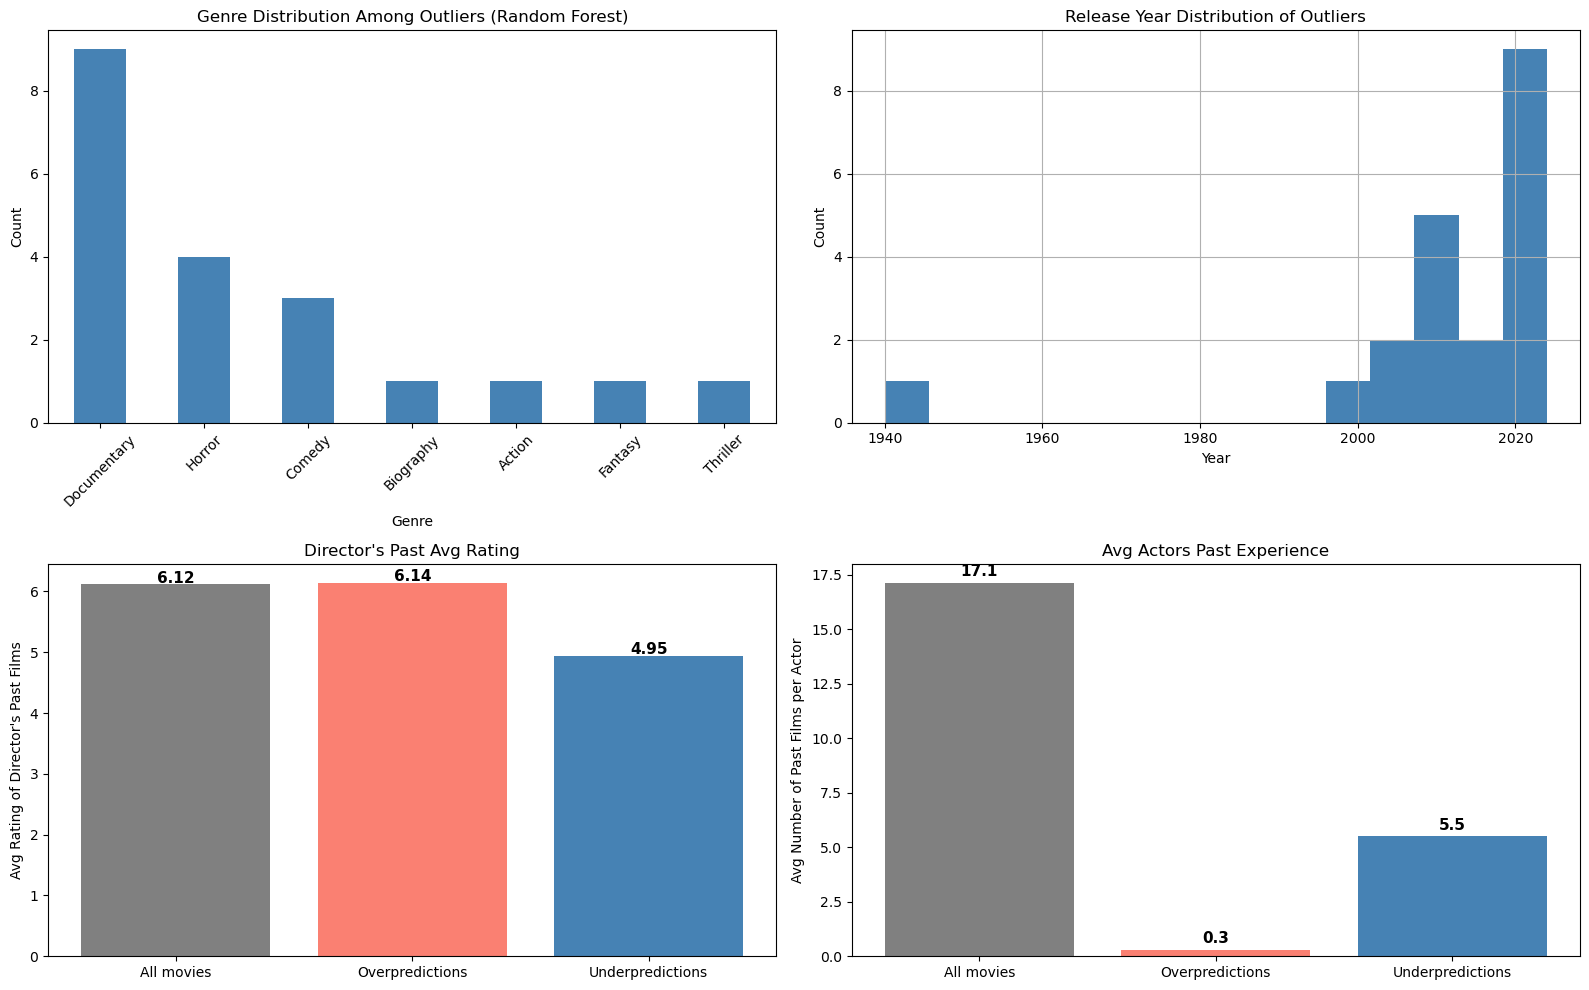

In [41]:
# 10.3 Pattern analysis 
FEAT_COLS = ['director_past_avg', 'avg_actors_past_exp']
groups    = ['All movies', 'Overpredictions', 'Underpredictions']
colors    = ['gray', 'salmon', 'steelblue']

all_means   = errors_df[FEAT_COLS].mean()
over_means  = over_rf[FEAT_COLS].mean()
under_means = under_rf[FEAT_COLS].mean()

# גרף 2×2
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

outliers_rf['first_genre'].value_counts().head(8).plot(
    kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Genre Distribution Among Outliers (Random Forest)')
axes[0, 0].set_xlabel('Genre')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)

outliers_rf['startYear'].hist(bins=15, ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('Release Year Distribution of Outliers')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Count')

dir_vals = [all_means['director_past_avg'],
            over_means['director_past_avg'],
            under_means['director_past_avg']]
bars = axes[1, 0].bar(groups, dir_vals, color=colors)
axes[1, 0].set_title("Director's Past Avg Rating")
axes[1, 0].set_ylabel("Avg Rating of Director's Past Films")
for bar, v in zip(bars, dir_vals):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2,
                    v + 0.02, f'{v:.2f}', ha='center', fontsize=11, fontweight='bold')

act_vals = [all_means['avg_actors_past_exp'],
            over_means['avg_actors_past_exp'],
            under_means['avg_actors_past_exp']]
bars = axes[1, 1].bar(groups, act_vals, color=colors)
axes[1, 1].set_title('Avg Actors Past Experience')
axes[1, 1].set_ylabel('Avg Number of Past Films per Actor')
for bar, v in zip(bars, act_vals):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2,
                    v + 0.3, f'{v:.1f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
### ניתוח של 20 ה - outlie לפי זאנרים(כמות או בינארי )


In [33]:
### 10.4 – השוואה בין המודלים
overlap_idx = outliers_rf.index.intersection(outliers_en.index)
print(f"חפיפה בין המודלים: {len(overlap_idx)} סרטים מתוך 20")
print(f"\nסרטים שמופיעים אצל שניהם:")
display(errors_df.loc[overlap_idx, ['primaryTitle', 'y_true', 'pred_rf', 'pred_en', 'error_rf', 'error_en']].round(2))


חפיפה בין המודלים: 10 סרטים מתוך 20

סרטים שמופיעים אצל שניהם:


,primaryTitle,y_true,pred_rf,pred_en,error_rf,error_en
71143,Justin Bieber: Always Believing,1.0,7.22,6.85,6.22,5.85
56724,Rape of the Soul,1.7,7.67,7.40,5.97,5.70
110039,Kurz,1.2,7.10,7.09,5.90,5.89
63593,Obama in NC: The Path to History,1.5,7.28,7.19,5.78,5.69
69244,Ramo Trip,1.4,7.14,7.25,5.74,5.85
93902,Tribalism Is Killing Us,1.3,6.83,6.86,5.53,5.56
71967,One Direction: I Love One Direction,9.2,4.58,4.90,-4.62,-4.30
108210,Long Shot Louie,8.1,3.65,3.24,-4.45,-4.86
110026,Another Year Together,8.9,4.51,4.28,-4.39,-4.62
4222,Herzensfreud - Herzensleid,8.6,4.28,2.88,-4.32,-5.72


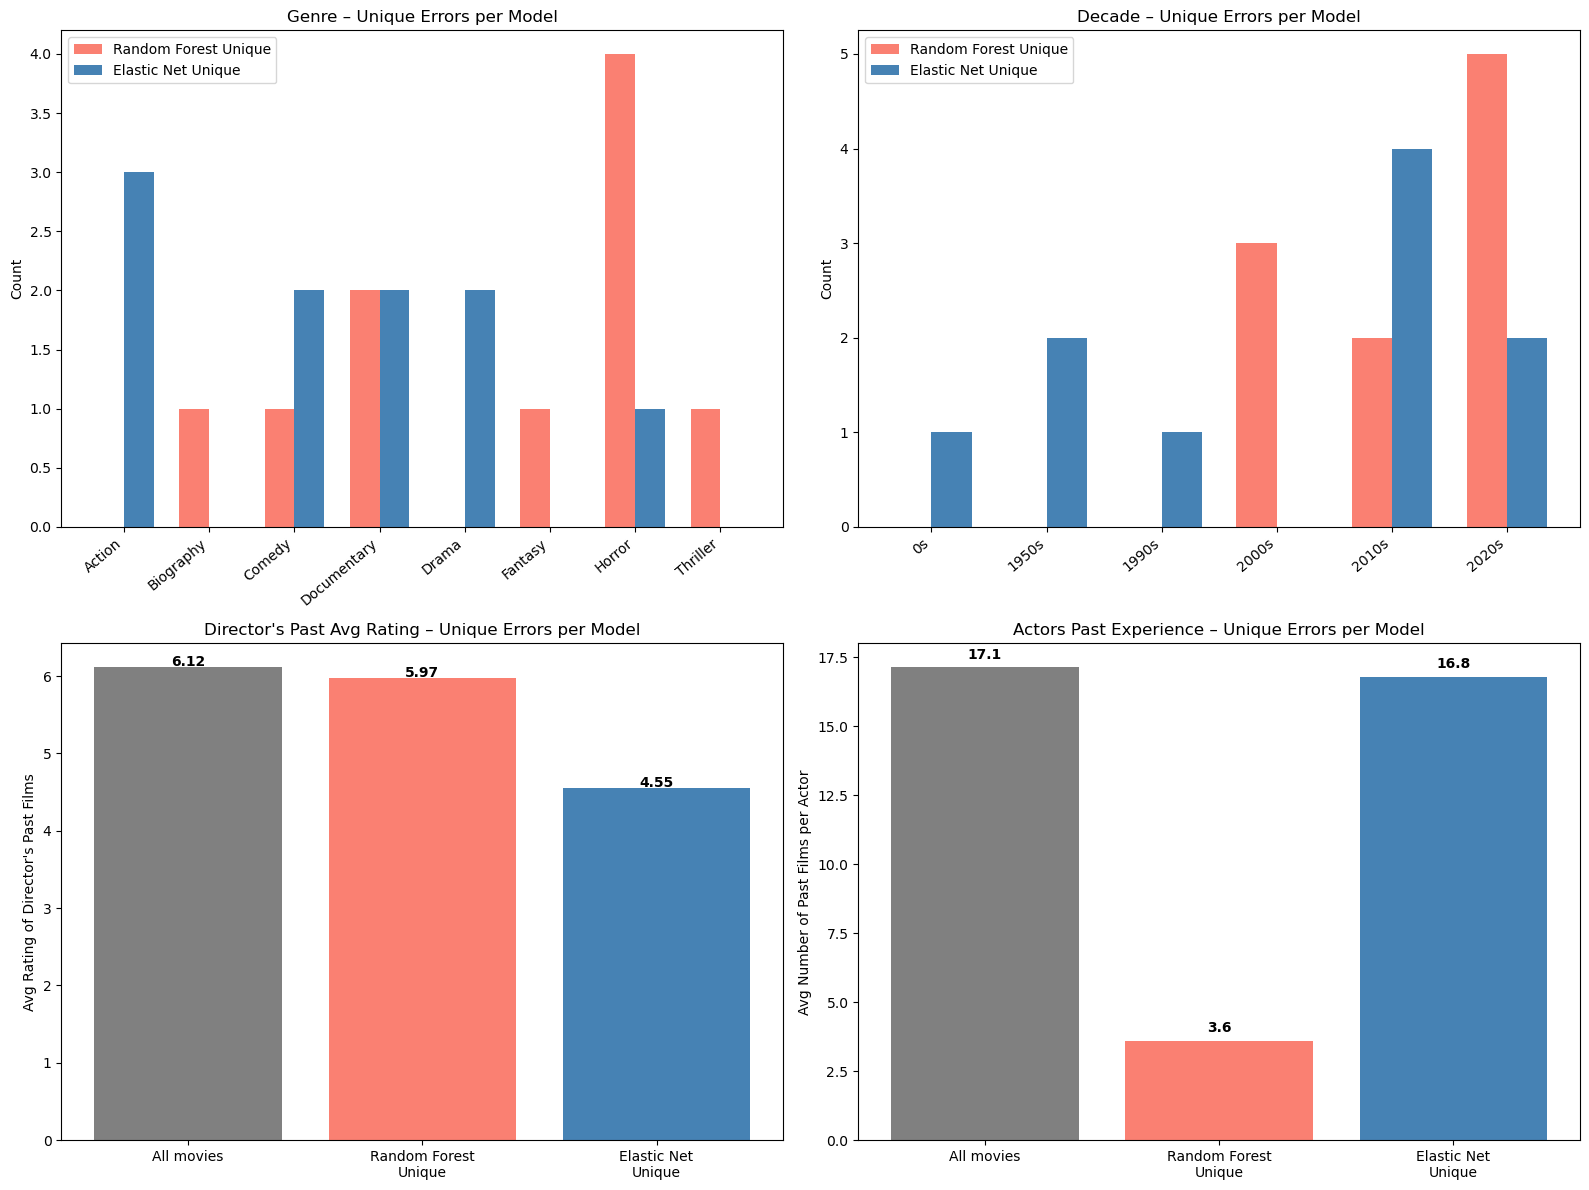

In [34]:
# השוואת שגיאות לפי כול מיני נתונים 
sub_best  = errors_df.loc[only_best]
sub_other = errors_df.loc[only_other]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# [0,0] – ז'אנר: שני המודלים על אותו גרף
genre_best  = sub_best['first_genre'].value_counts().head(6)
genre_other = sub_other['first_genre'].value_counts().head(6)
all_genres  = sorted(set(genre_best.index) | set(genre_other.index))
x = range(len(all_genres))
w = 0.35
axes[0, 0].bar([i - w/2 for i in x],
               [genre_best.get(g, 0)  for g in all_genres], w,
               label=f'{best_name} Unique',  color='salmon')
axes[0, 0].bar([i + w/2 for i in x],
               [genre_other.get(g, 0) for g in all_genres], w,
               label=f'{other_name} Unique', color='steelblue')
axes[0, 0].set_xticks(list(x))
axes[0, 0].set_xticklabels(all_genres, rotation=40, ha='right')
axes[0, 0].set_title('Genre – Unique Errors per Model')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend()
# [0,1] – עשור: שני המודלים על אותו גרף
dec_best  = (sub_best['startYear']  // 10 * 10).value_counts().sort_index()
dec_other = (sub_other['startYear'] // 10 * 10).value_counts().sort_index()
all_dec   = sorted(set(dec_best.index) | set(dec_other.index))
dec_labels = [f"{int(d)}s" for d in all_dec]
x = range(len(all_dec))
axes[0, 1].bar([i - w/2 for i in x],
               [dec_best.get(d, 0)  for d in all_dec], w,
               label=f'{best_name} Unique',  color='salmon')
axes[0, 1].bar([i + w/2 for i in x],
               [dec_other.get(d, 0) for d in all_dec], w,
               label=f'{other_name} Unique', color='steelblue')
axes[0, 1].set_xticks(list(x))
axes[0, 1].set_xticklabels(dec_labels, rotation=40, ha='right')
axes[0, 1].set_title('Decade – Unique Errors per Model')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend()
# [1,0] – Director Past Avg
overall_dir = errors_df['director_past_avg'].mean()
groups  = ['All movies', f'{best_name}\nUnique', f'{other_name}\nUnique']
dir_v   = [overall_dir,
           sub_best['director_past_avg'].mean(),
           sub_other['director_past_avg'].mean()]
colors  = ['gray', 'salmon', 'steelblue']
bars = axes[1, 0].bar(groups, dir_v, color=colors)
axes[1, 0].set_title("Director's Past Avg Rating – Unique Errors per Model")
axes[1, 0].set_ylabel("Avg Rating of Director's Past Films")
for bar, v in zip(bars, dir_v):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2,
                    v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')
# [1,1] – Actors Past Experience
overall_act = errors_df['avg_actors_past_exp'].mean()
act_v = [overall_act,
         sub_best['avg_actors_past_exp'].mean(),
         sub_other['avg_actors_past_exp'].mean()]
bars = axes[1, 1].bar(groups, act_v, color=colors)
axes[1, 1].set_title('Actors Past Experience – Unique Errors per Model')
axes[1, 1].set_ylabel('Avg Number of Past Films per Actor')
for bar, v in zip(bars, act_v):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2,
                    v + 0.3, f'{v:.1f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [31]:
# טבלת סיכום
summary_unique = pd.DataFrame({
    'Metric':              ['N (unique outliers)',
                            'Top Genre',
                            'Top Decade',
                            'Director Past Avg',
                            'Actors Past Exp'],
    f'{best_name} Unique': [
        len(sub_best),
        sub_best['first_genre'].value_counts().idxmax() if len(sub_best) > 0 else 'N/A',
        f"{int((sub_best['startYear'] // 10 * 10).value_counts().idxmax())}s" if len(sub_best) > 0 else 'N/A',
        f"{sub_best['director_past_avg'].mean():.2f}",
        f"{sub_best['avg_actors_past_exp'].mean():.1f}",],
    f'{other_name} Unique': [
        len(sub_other),
        sub_other['first_genre'].value_counts().idxmax() if len(sub_other) > 0 else 'N/A',
        f"{int((sub_other['startYear'] // 10 * 10).value_counts().idxmax())}s" if len(sub_other) > 0 else 'N/A',
        f"{sub_other['director_past_avg'].mean():.2f}",
        f"{sub_other['avg_actors_past_exp'].mean():.1f}",],
    'All movies': [
        len(errors_df),
        errors_df['first_genre'].value_counts().idxmax(),
        f"{int((errors_df['startYear'] // 10 * 10).value_counts().idxmax())}s",
        f"{errors_df['director_past_avg'].mean():.2f}",
        f"{errors_df['avg_actors_past_exp'].mean():.1f}",],
}).set_index('Metric')
print("── Summary: Unique Errors per Model vs All movies ──")
display(summary_unique)

── Summary: Unique Errors per Model vs All movies ──


,Random Forest Unique,Elastic Net Unique,All movies
Metric,,,
N (unique outliers),10,10,115560
Top Genre,Horror,Action,Drama
Top Decade,2020s,2010s,2010s
Director Past Avg,5.97,4.55,6.12
Actors Past Exp,3.6,16.8,17.1


<div dir="rtl">
ניתוח שגיאות ייחודיות לכל מודל

Random Forest – שגיאות ייחודיות:
RF טעה בעיקר על סרטי Horror (4 מתוך 10) משנות ה-2020 — ז'אנר שגדל מאוד בשנים האחרונות ומכיל הרבה תוכן נישתי עם קהל נאמן. המאפיין הבולט: שחקנים עם ניסיון נמוך מאוד (ממוצע 3.6 לעומת 17.1 בכלל הדאטה), כלומר RF מתקשה עם סרטי Horror חדשים שמשלבים שחקנים לא מוכרים.

Elastic Net – שגיאות ייחודיות:
EN טעה בעיקר על סרטי Action (3 מתוך 10) משנות ה-2010, עם במאים שהיסטוריית הדירוגים שלהם נמוכה משמעותית (4.55 לעומת 6.12 בממוצע). בניגוד ל-RF, שחקני ה-EN outliers מנוסים מאוד (16.8 — כמעט זהה לממוצע הכללי), כלומר EN מתקשה עם סרטי Action של במאים חלשים, גם כשהשחקנים מוכרים.

המסקנה המרכזית:
שני המודלים נכשלים בנקודות שונות —

RF עיוור לסרטי Horror עם שחקנים חדשים
EN עיוור לסרטי Action של במאים עם היסטוריה גרועה
# לבדוק אם יש הבדל כשיש רק זאנר אחד או יותר 
</div>

## 11. ניתוח הוגנות (Fairness Analysis)

In [35]:
# ── 11.1 Setup ───────────────────────────────────────────────
fairness_df = errors_df.copy()
fairness_df['decade'] = (fairness_df['startYear'] // 10 * 10).astype('Int64')
overall_rmse = np.sqrt(mean_squared_error(fairness_df['y_true'], fairness_df['pred_rf']))
overall_mae  = mean_absolute_error(fairness_df['y_true'], fairness_df['pred_rf'])
def slice_metrics(df, label):
    rmse = np.sqrt(mean_squared_error(df['y_true'], df['pred_rf']))
    mae  = mean_absolute_error(df['y_true'], df['pred_rf'])
    pct  = (rmse / overall_rmse - 1) * 100
    return {'Slice': label, 'N': len(df),
            'RMSE': round(rmse, 4), 'MAE': round(mae, 4),
            'RMSE vs overall': f'{pct:+.1f}%'}

In [36]:
# ── 11.2 By Genre (top 5, multi-label) ───────────────────────
genre_rows = []
for _, row in fairness_df.iterrows():
    for g in (row['genres'] if isinstance(row['genres'], list) else []):
        genre_rows.append(row.to_dict() | {'genre_label': g})
genre_long  = pd.DataFrame(genre_rows)
top5_genres = genre_long['genre_label'].value_counts().head(5).index
genre_df = pd.DataFrame([
    slice_metrics(genre_long[genre_long['genre_label'] == g], g)
    for g in top5_genres
])

── RMSE / MAE by Genre (top 5) ──


,Slice,N,RMSE,MAE,RMSE vs overall
0,Drama,58460,1.0202,0.7763,-5.4%
1,Comedy,33316,1.0864,0.8277,+0.8%
2,Romance,15693,0.9779,0.7435,-9.3%
3,Action,13987,1.1527,0.8842,+6.9%
4,Documentary,13014,1.0191,0.7581,-5.5%



── RMSE / MAE by Decade ──


,Slice,N,RMSE,MAE,RMSE vs overall
0,1910s,171,0.8316,0.6098,-22.9%
1,1920s,785,0.9858,0.7319,-8.6%
2,1930s,3121,0.7931,0.5874,-26.4%
3,1940s,3292,0.7671,0.5725,-28.8%
4,1950s,4602,0.8469,0.6462,-21.4%
5,1960s,6208,0.9210,0.7139,-14.6%
6,1970s,7969,0.9432,0.7323,-12.5%
7,1980s,9631,0.9809,0.7586,-9.0%
8,1990s,10213,1.0197,0.7886,-5.4%
9,2000s,17555,1.1234,0.8569,+4.2%


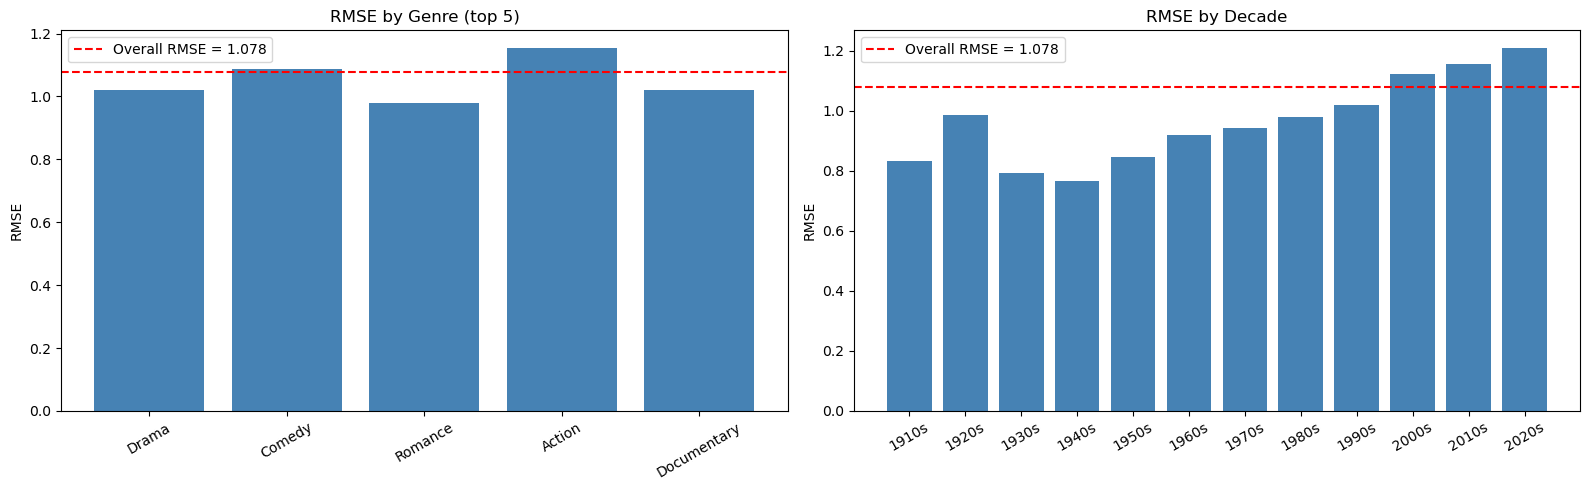

In [16]:
# ── 11.3 By Decade ───────────────────────────────────────────
decade_df = pd.DataFrame([
    slice_metrics(sub, f"{int(decade)}s")
    for decade, sub in fairness_df.groupby('decade')
    if len(sub) >= 30
])
# ── Tables ───────────────────────────────────────────────────
print("── RMSE / MAE by Genre (top 5) ──")
display(genre_df)
print("\n── RMSE / MAE by Decade ──")
display(decade_df)
# ── Bar Charts ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(genre_df['Slice'], genre_df['RMSE'], color='steelblue')
axes[0].axhline(overall_rmse, color='red', linestyle='--',
                label=f'Overall RMSE = {overall_rmse:.3f}')
axes[0].set_title('RMSE by Genre (top 5)')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend()
axes[1].bar(decade_df['Slice'], decade_df['RMSE'], color='steelblue')
axes[1].axhline(overall_rmse, color='red', linestyle='--',
                label=f'Overall RMSE = {overall_rmse:.3f}')
axes[1].set_title('RMSE by Decade')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()
plt.tight_layout()
plt.show()

## 12. שמירת מודל סופי + prepare_data

### prepare_data

מקבלת רק את דאטת התחרות.
ניגשת ל-`df_train_global` שנשמר בזיכרון ה-notebook –
כך הפיצ'רים ההיסטוריים מחושבים על בסיס דאטת האימון.

<div dir="rtl">
כדי שבזמן הגנת הפרויקט הוא יוכל לטעון אותו בשנייה אחת ולבחון אותו על סרטים חדשים, בלי לחכות שהקוד יתאמן מחדש
הקוד הזה ייצור לך קובץ בשם model.pkl בתיקייה, ואותו את מעלה לגיטהאב.
</div>

In [ ]:
import joblib

# נשמור את המודל המוביל שלך (למשל, ה-Pipeline של ה-Random Forest)
joblib.dump(best_rf_model, 'model.pkl')
print("המודל נשמר בהצלחה כ-model.pkl!")